In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import fates_calibration_library.clm_functions as clm
import fates_calibration_library.utils as utils
import fates_calibration_library.analysis_functions as analysis

In [2]:
# Setup PBSCluster
cluster = PBSCluster(
    cores=1,                                                   # The number of cores you want
    memory='40GB',                                             # Amount of memory
    processes=1,                                               # How many processes
    queue='casper',                                            # The type of queue to utilize
    local_directory='/glade/work/afoster',                     # Use your local directory
    resource_spec='select=1:ncpus=1:mem=25GB',                 # Specify resources
    log_directory='/glade/derecho/scratch/afoster/dask_logs',  # log directory
    account='P08010000',                                       # Input your project ID here
    walltime='10:00:00',                                       # Amount of wall time
    interface='ext')                                           # Interface to use

In [3]:
cluster.scale(60)
dask.config.set({
    'distributed.dashboard.link': 'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
})
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.203:44843,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B


In [7]:
fates_vars = ['FATES_FRACTION', 'FATES_GPP', 'FATES_LAI', 'QVEGE',
              'QSOIL', 'QVEGT', 'EFLX_LH_TOT', 'FSH', 'FSR', 'FSDS', 'FSA',
              'FIRE', 'FLDS', 'FCTR', 'FCEV', 'FGEV', 'BTRANMN',
              'FGR', 'SOILWATER_10CM', 'TWS', 'QRUNOFF', 'SNOWDP',
              'TV', 'TG', 'TSA', 'RH2M', 'SNOW', 'RAIN', 'FGR12',
              'TREFMXAV', 'TREFMNAV']

clm_vars = ['FPSN', 'TLAI', 'QVEGE', 'QVEGT', 'QSOIL', 'EFLX_LH_TOT', 'FSH',
            'FSR', 'FSDS', 'FSA', 'FIRE', 'FLDS', 'FCTR', 'FCEV',
            'FGEV', 'BTRANMN', 'FGR', 'SOILWATER_10CM', 'TWS',
            'QRUNOFF', 'SNOWDP', 'TV', 'TG', 'TSA', 'RH2M', 'SNOW', 'RAIN',
            'FGR12', 'TREFMXAV', 'TREFMNAV']

out_vars = ['GPP', 'LAI', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM', 'ASA',
            'FSDS', 'FSR', 'FSA', 'FIRE', 'RLNS', 'RN', 'BTRANMN', 'TV', 'Temp',
            'RH2M', 'Precip', 'QRUNOFF', 'QSOIL', 'QVEGT', 'QVEGE']

In [13]:
def process_ds(ds, years, filter_nyears):
    mod_years = np.unique(ds.time.dt.year)
    last_n = mod_years[-filter_nyears:]
    ds = ds.sel(time=slice(f"{last_n[0]}-01-01", f"{last_n[-1]}-12-31"))
    ds["time"] = xr.cftime_range(str(years[0]), periods=len(ds.time), freq="MS")

    return ds

In [8]:
# config file with conversion information in it
var_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/model_conversion.yaml'
var_dict = utils.get_config_file(var_config)

In [9]:
dir = '/glade/derecho/scratch/afoster/archive/ctsm60SP_fates_dompft/lnd/hist'
files = sorted([os.path.join(dir, f) for f in os.listdir(dir)])

In [15]:
dircheck = '/glade/derecho/scratch/afoster/archive/ctsm60SP_fates_dompft_/lnd/hist'
filescheck = sorted([os.path.join(dircheck, f) for f in os.listdir(dircheck)])

In [10]:
ds = clm.get_clm_ds(files, fates_vars, 2000)

In [16]:
ds_check = clm.get_clm_ds(filescheck, fates_vars, 2000)

In [11]:
filter_nyears = 20
years = [2000, 2014]

In [14]:
ds = process_ds(ds, years, filter_nyears)

In [14]:
ds_check = process_ds(ds_check, years, filter_nyears)

In [18]:
diff = (ds_check.GPP - ds.GPP)

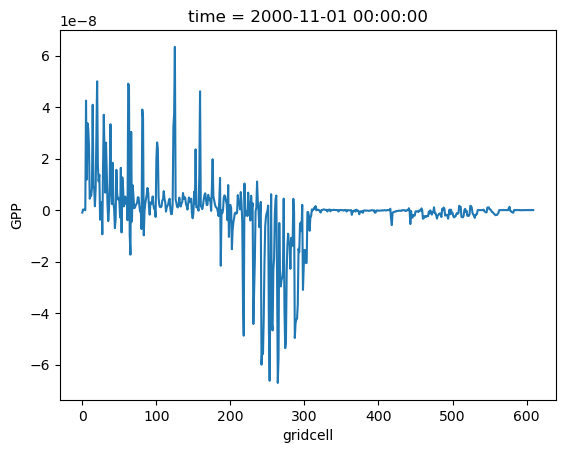

In [20]:
diff.isel(time=10).plot()

In [119]:
mesh_dir = '/glade/work/afoster/FATES_calibration/mesh_files'
land_mask_file = os.path.join(mesh_dir, 'dominant_grid.nc')
mesh_file = os.path.join(mesh_dir, 'dominant_grid_mesh.nc')
grids = get_pft_grids(land_mask_file, mesh_file, 1)

In [120]:
land_frac_ds_file = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")

In [121]:
ds_pft = ds.where(ds.gridcell.isin(grids), drop=True)

In [122]:
ds_pft = attach_land_area(ds_pft, grids, land_frac_ds_file)

In [123]:
annual_means = clm.apply_to_vars(
    ds_pft,
    out_vars,
    func=analysis.calculate_annual_mean,
    add_sparse=True,
    conversion_factor={
        var: var_dict[var]["time_conversion_factor"] for var in out_vars
    },
    new_units={var: var_dict[var]["annual_units"] for var in out_vars},
)

In [125]:
mean_gpp = (annual_means.GPP.mean(dim='year'))*ds_pft.land_frac

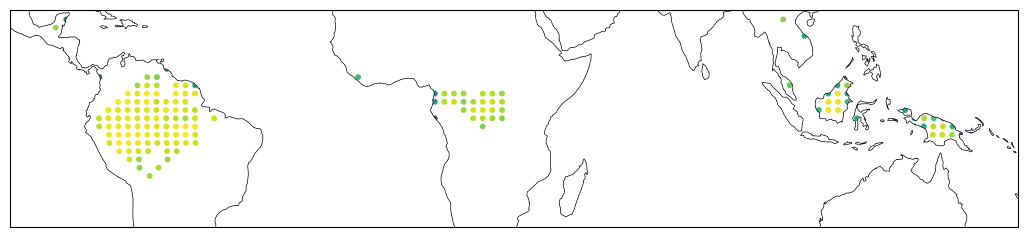

In [126]:
fig, ax = plt.subplots(figsize=(13, 6), subplot_kw=dict(projection=ccrs.Robinson()))
ax.coastlines()
ocean = ax.add_feature(
        cfeature.NaturalEarthFeature("physical", "ocean", "110m", facecolor="white")
)
scatter = ax.scatter(
    df_pft.lon,
    df_pft.lat,
    s=10,
    c=df_pft.gpp,
    #edgecolor="black",
    cmap='viridis',
    transform=ccrs.PlateCarree(),
)

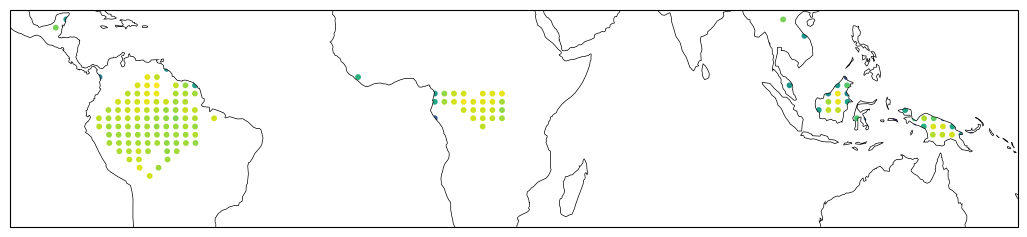

In [127]:
fig, ax = plt.subplots(figsize=(13, 6), subplot_kw=dict(projection=ccrs.Robinson()))
ax.coastlines()
ocean = ax.add_feature(
        cfeature.NaturalEarthFeature("physical", "ocean", "110m", facecolor="white")
)
scatter = ax.scatter(
    annual_means.grid1d_lon,
    annual_means.grid1d_lat,
    s=10,
    c=mean_gpp,
    #edgecolor="black",
    cmap='viridis',
    transform=ccrs.PlateCarree(),
)

In [50]:
df = pd.read_csv(os.path.join(mesh_dir, 'dominant_grid.csv'))